In [1]:
import pandas as pd

In [2]:
pwd

'e:\\Software Python\\UCT Internship\\Churnsense\\notebooks'

In [3]:
df=pd.read_csv(r"E:\\Software Python\\UCT Internship\\Churnsense\\Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


EDA : Step-by-Step

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')
df["TotalCharges"].isnull().sum()

np.int64(11)

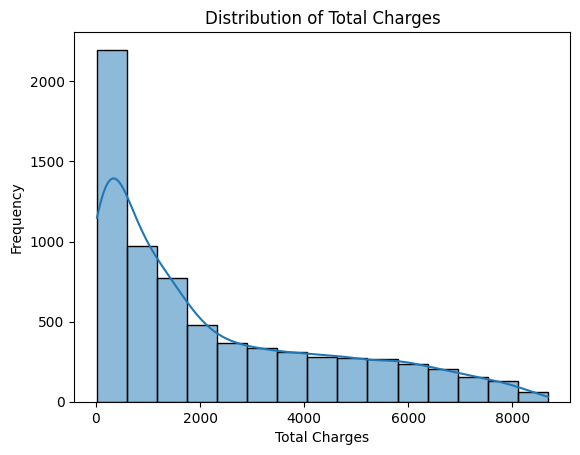

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['TotalCharges'], bins=15, kde=True)
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Total Charges')
plt.show()

In [10]:
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
df["TotalCharges"].isnull().sum()

C:\Users\valka\AppData\Local\Temp\ipykernel_8716\3310692450.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


np.int64(0)

In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
print("% of Churn",)

% of Churn


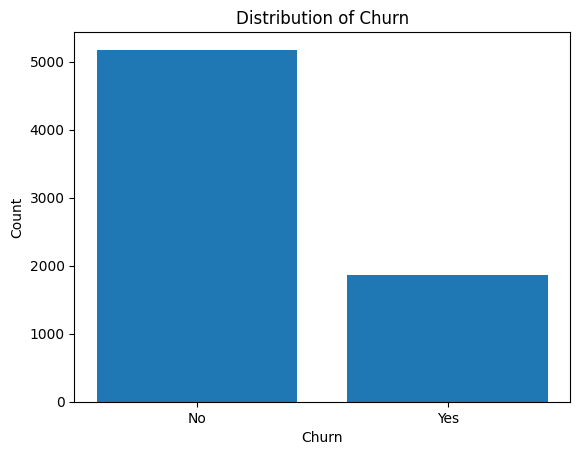

In [13]:
plt.bar(df['Churn'].value_counts().index, df['Churn'].value_counts().values)
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Distribution of Churn')
plt.show()

In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

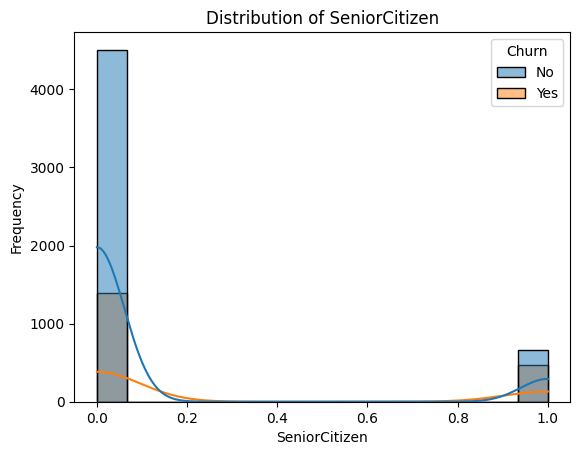

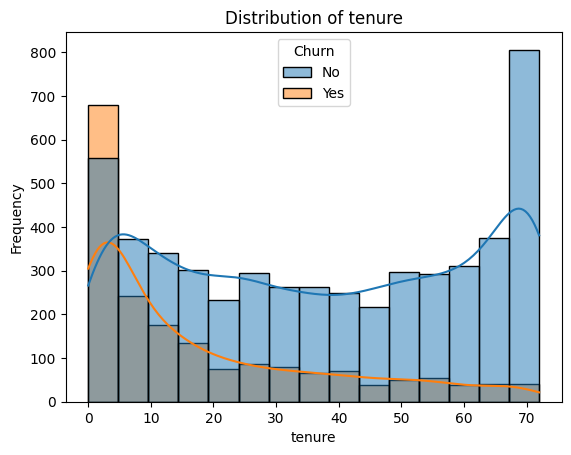

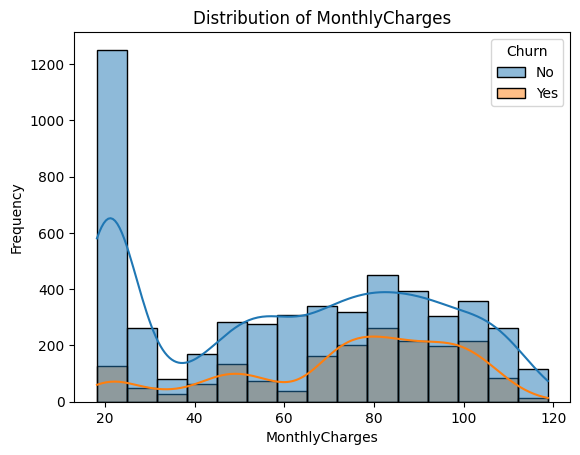

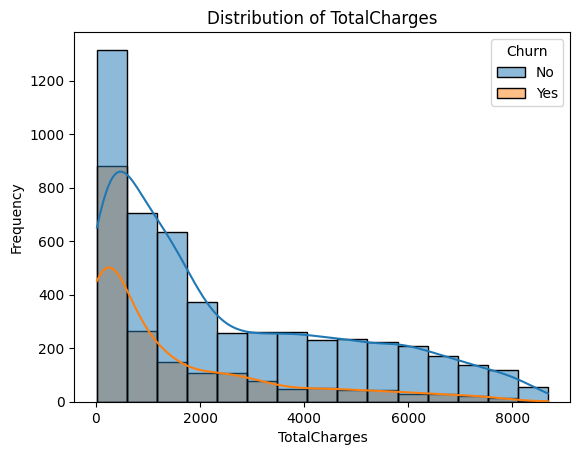

In [15]:
for i in num_cols:
    sns.histplot(data=df,x=i,hue="Churn",bins=15,kde=True)
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {i}')
    plt.show()

In [16]:
print(df['Churn'].unique())

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [17]:
for col in df.select_dtypes(include='object').columns:
    if col != "customerID":
        churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == "Yes").mean() * 100)
        print(f"\n")
        print(churn_rate)

C:\Users\valka\AppData\Local\Temp\ipykernel_8716\549425832.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:




gender
Female    26.920872
Male      26.160338
Name: Churn, dtype: float64


Partner
No     32.957979
Yes    19.664903
Name: Churn, dtype: float64


Dependents
No     31.279140
Yes    15.450237
Name: Churn, dtype: float64


PhoneService
No     24.926686
Yes    26.709637
Name: Churn, dtype: float64


MultipleLines
No                  25.044248
No phone service    24.926686
Yes                 28.609896
Name: Churn, dtype: float64


InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64


OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Churn, dtype: float64


OnlineBackup
No                     39.928756
No internet service     7.404980
Yes                    21.531494
Name: Churn, dtype: float64


DeviceProtection
No                     39.127625
No internet service     7.404980
Yes                    22.502064
Name: Churn, dtype: float64


TechSuppor

In [18]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [19]:
df.select_dtypes(include=["int64", "float64"]).corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.102652,0.150889
tenure,0.016567,1.000000,0.247900,0.825464,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.650864,0.193356
TotalCharges,0.102652,0.825464,0.650864,1.000000,-0.199037
Churn,0.150889,-0.352229,0.193356,-0.199037,1.000000


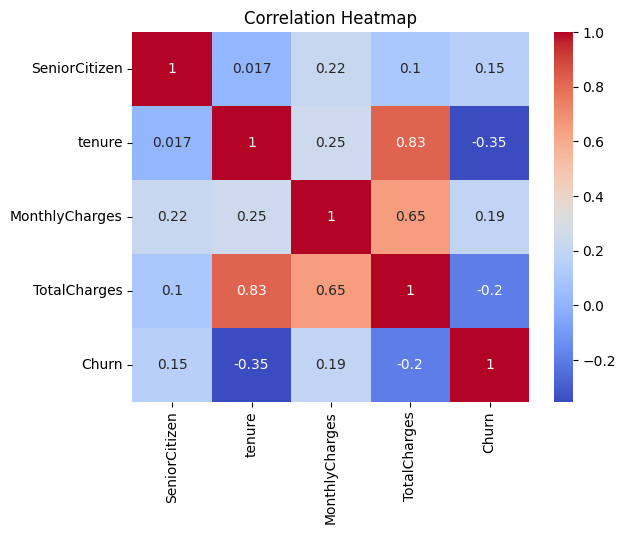

In [20]:
sns.heatmap(df.select_dtypes(include=["int64", "float64"]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Total Charges and Tenure are postively correlated to each other.
The total Charges depends on Tenure. The longer they stay, higher the total chargers.

Total Charges and Monthly Charges are postively correlated to each other.
The higher monthly charges results in Cumulative Total Revenue.

Tenure and Churn are negatively correlated.
Longer the customer stays, less the chance they churn.

In [2]:
df.drop(columns=["customerID"], inplace=True)

NameError: name 'df' is not defined

In [22]:
cat_col=df.select_dtypes(include=["object","str"]).columns

In [24]:
x=df.drop(columns=["Churn"])
y=df["Churn"]

In [25]:
num_cols = x.select_dtypes(include=['int64', 'float64']).columns
cat_cols = x.select_dtypes(include=['object', 'str']).columns

Feature Engineering

In [26]:
x["tenure_group"] = pd.cut(x["tenure"], bins=[0, 12, 24, 48, 60, float('inf')], labels=['0-12', '13-24', '25-48', '49-60', '60+'])

In [27]:
x["monthly_per_tenure"]=x["TotalCharges"]/(x["tenure"]+1)

In [28]:
services=["PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
x["num_services"]=x[services].apply(lambda row: sum(row=="Yes"), axis=1)

Preprocessing Pipeline

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x[num_cols] = scaler.fit_transform(x[num_cols])
x[num_cols].head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,-0.439916,-1.277445,-1.160323,-0.994242
1,-0.439916,0.066327,-0.259629,-0.173244
2,-0.439916,-1.236724,-0.362660,-0.959674
3,-0.439916,0.514251,-0.746535,-0.194766
4,-0.439916,-1.236724,0.197365,-0.940470


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    x[col] = le.fit_transform(x[col])
x[cat_cols].head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2
1,1,0,0,1,0,0,2,0,2,0,0,0,1,0,3
2,1,0,0,1,0,0,2,2,0,0,0,0,0,1,3
3,1,0,0,0,1,0,2,0,2,2,0,0,1,0,0
4,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2


In [33]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,stratify=y, random_state=42)